# Glucose Level Prediction using Polynomial Regression

This notebook trains a Polynomial Regression model to predict glucose levels from PPG signal features.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Feature Dataset

In [2]:
# Load the extracted features
df = pd.read_csv('data/ppg_raw_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (67, 36)

First few rows:


,filename,patient_id,gender,age,glucose_level,height,weight,mean,std,median,...,vlf_power,lf_power,hf_power,total_power,lf_hf_ratio,lf_norm,hf_norm,dominant_frequency,dominant_power,spectral_entropy
0,signal_01_0001.csv,1,Male,38,99,180,53,511.866895,4.514426,511.0,...,26463.643784,76374.531102,4.564709e+05,1.953509e+07,0.167315,0.143333,0.856667,2.583333,6.716522e+06,6.895073
1,signal_01_0002.csv,1,Male,38,102,180,53,513.258767,2.919033,513.0,...,53770.332346,155215.193410,6.666069e+05,3.687807e+07,0.232844,0.188867,0.811133,2.577778,2.398001e+07,4.075505
2,signal_01_0003.csv,1,Male,38,103,180,53,512.897489,4.765452,511.0,...,3597.197443,10286.638201,1.134210e+05,3.146832e+07,0.090694,0.083153,0.916847,2.577778,2.856094e+06,8.377584
3,signal_01_0004.csv,1,Male,38,128,180,53,512.083790,6.402309,511.0,...,151530.183009,436864.190334,2.079298e+06,8.113965e+07,0.210102,0.173623,0.826377,2.577778,5.607089e+07,3.522607
4,signal_01_0005.csv,1,Male,38,130,180,53,511.439635,2.096172,512.0,...,35749.451550,102999.455132,4.775175e+05,3.540353e+07,0.215698,0.177427,0.822573,2.572222,7.125875e+06,7.709672


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\nTarget variable (glucose_level) statistics:")
print(df['glucose_level'].describe())

Missing values:
filename               0
patient_id             0
gender                 0
age                    0
glucose_level          0
height                 0
weight                 0
mean                   0
std                    0
median                 0
min                    0
max                    0
range                  0
skewness               0
kurtosis               0
num_peaks              0
mean_peak_amplitude    0
std_peak_amplitude     0
mean_hr                0
std_hr                 0
min_hr                 0
max_hr                 0
rmssd                  0
sdnn                   0
mean_pulse_width       0
std_pulse_width        0
vlf_power              0
lf_power               0
hf_power               0
total_power            0
lf_hf_ratio            0
lf_norm                0
hf_norm                0
dominant_frequency     0
dominant_power         0
spectral_entropy       0
dtype: int64

Target variable (glucose_level) statistics:
count     67.000000
mean  

## 2. Feature Selection

Based on the correlation analysis from `raw_signal_analysis.ipynb`, we'll use **ONLY the top 8 features** to prevent overfitting:

**Top Correlations (Absolute Value):**
- mean_hr (0.305) - Mean Heart Rate
- num_peaks (0.296) - Number of Peaks  
- sdnn (-0.206) - Heart Rate Variability
- skewness (0.202) - Signal Skewness
- age (0.197) - Patient Age
- kurtosis (-0.196) - Signal Kurtosis
- lf_hf_ratio (-0.184) - LF/HF Power Ratio
- weight (0.181) - Patient Weight

**Simplified model: 8 features for 67 samples (better ratio to prevent overfitting).**

In [4]:
# Select ONLY top 8 features to prevent overfitting
top_features = [
    'mean_hr',      # 0.305 correlation
    'num_peaks',    # 0.296 correlation
    'sdnn',         # -0.206 correlation
    'skewness',     # 0.202 correlation
    'age',          # 0.197 correlation
    'kurtosis',     # -0.196 correlation
    'lf_hf_ratio',  # -0.184 correlation
    'weight'        # 0.181 correlation
]

print(f"Selected {len(top_features)} features for modeling (reduced from 20):")
print("=" * 60)
for i, feat in enumerate(top_features, 1):
    print(f"  {i}. {feat}")
    
print(f"\nFeature-to-sample ratio: {len(top_features)}/67 = {len(top_features)/67:.3f}")


Selected 8 features for modeling (reduced from 20):
  1. mean_hr
  2. num_peaks
  3. sdnn
  4. skewness
  5. age
  6. kurtosis
  7. lf_hf_ratio
  8. weight

Feature-to-sample ratio: 8/67 = 0.119


## 3. Prepare Data for Training

In [5]:
# Prepare features and target
X = df[top_features].copy()
y = df['glucose_level'].copy()

# Handle any remaining missing values
X = X.fillna(X.mean())

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature statistics:")
X.describe()

Feature matrix shape: (67, 8)
Target vector shape: (67,)

Feature statistics:


,mean_hr,num_peaks,sdnn,skewness,age,kurtosis,lf_hf_ratio,weight
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,93.807915,280.895522,0.194335,-1.602858,31.313433,17.860008,0.162638,69.194030
std,3.517725,10.460799,0.021002,2.716205,9.434317,22.560571,0.064953,17.020699
min,83.407516,250.000000,0.150519,-9.025553,22.000000,-0.045349,0.003559,42.000000
25%,91.920738,275.500000,0.181629,-3.488575,24.000000,2.290896,0.136401,56.000000
50%,94.215103,282.000000,0.194054,-0.646354,29.000000,7.340489,0.178139,62.000000
75%,95.620888,286.500000,0.206693,0.580288,38.000000,30.142417,0.215767,88.000000
max,101.123802,303.000000,0.278310,1.637116,61.000000,93.435082,0.255574,103.000000


In [6]:
# Split data by patient ID to prevent data leakage
# Get unique patient IDs
unique_patients = df['patient_id'].unique()
print(f"Total unique patients: {len(unique_patients)}")

# Split patients (not individual samples) into train and test
train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training patients: {len(train_patients)}")
print(f"Test patients: {len(test_patients)}")

# Create masks to filter data by patient
train_mask = df['patient_id'].isin(train_patients)
test_mask = df['patient_id'].isin(test_patients)

# Split features and target by patient
X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()

print(f"\nTraining set: {X_train.shape[0]} samples from {len(train_patients)} patients")
print(f"Test set: {X_test.shape[0]} samples from {len(test_patients)} patients")
print(f"\nTraining target range: {y_train.min():.0f} - {y_train.max():.0f} mg/dL")
print(f"Test target range: {y_test.min():.0f} - {y_test.max():.0f} mg/dL")

# Verify no patient overlap
assert len(set(train_patients) & set(test_patients)) == 0, "ERROR: Patient overlap detected!"


Total unique patients: 23
Training patients: 18
Test patients: 5

Training set: 50 samples from 18 patients
Test set: 17 samples from 5 patients

Training target range: 88 - 183 mg/dL
Test target range: 94 - 183 mg/dL


In [7]:
# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"Mean of scaled training features: {X_train_scaled.mean():.4f}")
print(f"Std of scaled training features: {X_train_scaled.std():.4f}")

Features scaled using StandardScaler
Mean of scaled training features: -0.0000
Std of scaled training features: 1.0000


## 4. Train Polynomial Regression Model

In [8]:
# Train Polynomial Regression with Ridge regularization
# Using degree 2 to capture non-linear relationships while preventing overfitting

# Create polynomial regression pipeline
# StandardScaler is already applied, so we add PolynomialFeatures + Ridge
poly_features = PolynomialFeatures(degree=2, include_bias=False)
ridge_reg = Ridge(alpha=10.0, random_state=42)  # Regularization to prevent overfitting

# Create pipeline
model = Pipeline([
    ('poly', poly_features),
    ('ridge', ridge_reg)
])

# Fit the model
model.fit(X_train_scaled, y_train)

print("Polynomial Regression Model Trained")
print("=" * 60)
print(f"Polynomial degree: 2")
print(f"Ridge regularization alpha: 10.0")
print(f"Number of polynomial features: {model.named_steps['poly'].n_output_features_}")
print(f"Original features: {len(top_features)}")

Polynomial Regression Model Trained
Polynomial degree: 2
Ridge regularization alpha: 10.0
Number of polynomial features: 44
Original features: 8


## 5. Model Evaluation

In [9]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  RMSE: {train_rmse:.2f} mg/dL")
print(f"  MAE:  {train_mae:.2f} mg/dL")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Set:")
print(f"  RMSE: {test_rmse:.2f} mg/dL")
print(f"  MAE:  {test_mae:.2f} mg/dL")
print(f"  R²:   {test_r2:.4f}")

print(f"\nOverfitting Check:")
print(f"  RMSE difference: {abs(train_rmse - test_rmse):.2f} mg/dL")
print(f"  R² difference:   {abs(train_r2 - test_r2):.4f}")

MODEL PERFORMANCE METRICS

Training Set:
  RMSE: 11.83 mg/dL
  MAE:  8.55 mg/dL
  R²:   0.4949

Test Set:
  RMSE: 22.22 mg/dL
  MAE:  17.25 mg/dL
  R²:   0.0099

Overfitting Check:
  RMSE difference: 10.39 mg/dL
  R² difference:   0.4851


In [10]:
# Cross-validation for more robust evaluation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    model, X_train_scaled, y_train, 
    cv=kfold, 
    scoring='neg_root_mean_squared_error'
)

print("\n5-Fold Cross-Validation Results:")
print(f"  CV RMSE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f} mg/dL")
print(f"  Individual fold RMSEs: {[-score for score in cv_scores]}")


5-Fold Cross-Validation Results:
  CV RMSE: 20.75 ± 5.29 mg/dL
  Individual fold RMSEs: [np.float64(29.658448591156816), np.float64(14.446138747538667), np.float64(17.123116364487085), np.float64(23.1524745018394), np.float64(19.372294512214413)]


## 6. Prediction Visualization

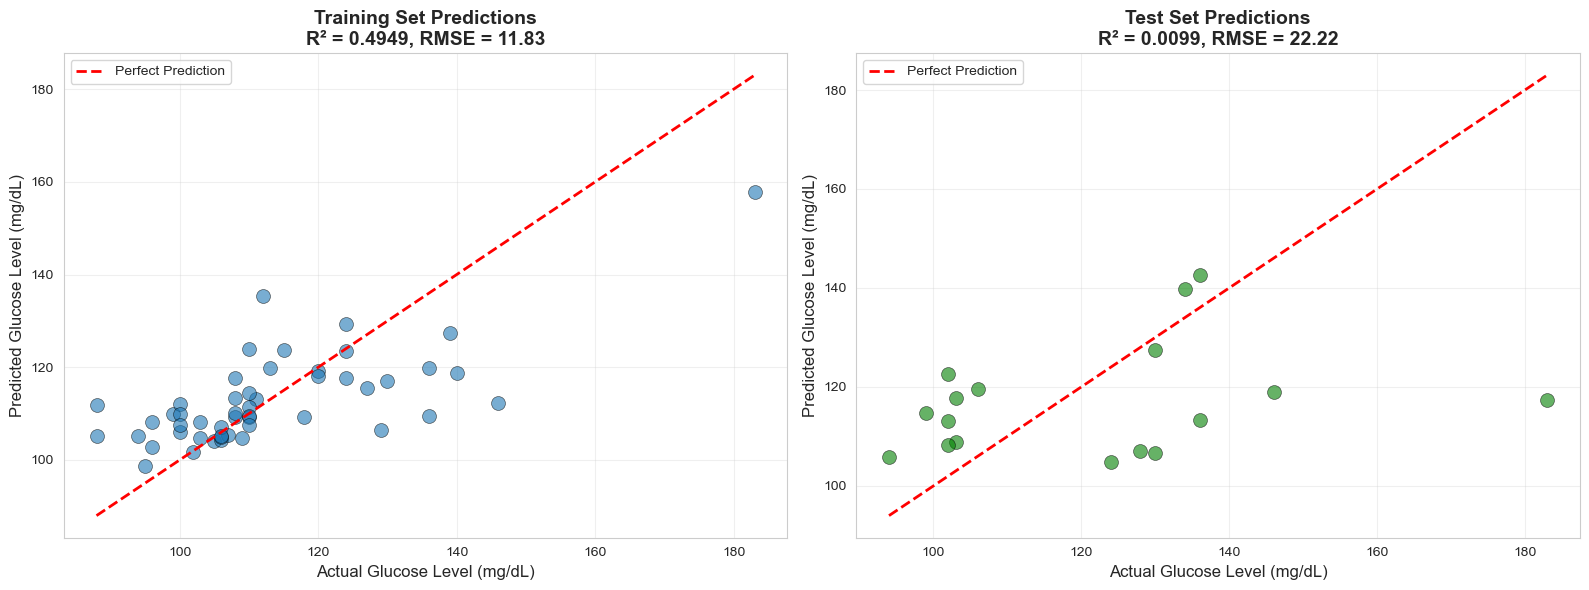

In [11]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Glucose Level (mg/dL)', fontsize=12)
axes[0].set_ylabel('Predicted Glucose Level (mg/dL)', fontsize=12)
axes[0].set_title(f'Training Set Predictions\nR² = {train_r2:.4f}, RMSE = {train_rmse:.2f}', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=100, color='green', 
                edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Glucose Level (mg/dL)', fontsize=12)
axes[1].set_ylabel('Predicted Glucose Level (mg/dL)', fontsize=12)
axes[1].set_title(f'Test Set Predictions\nR² = {test_r2:.4f}, RMSE = {test_rmse:.2f}', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

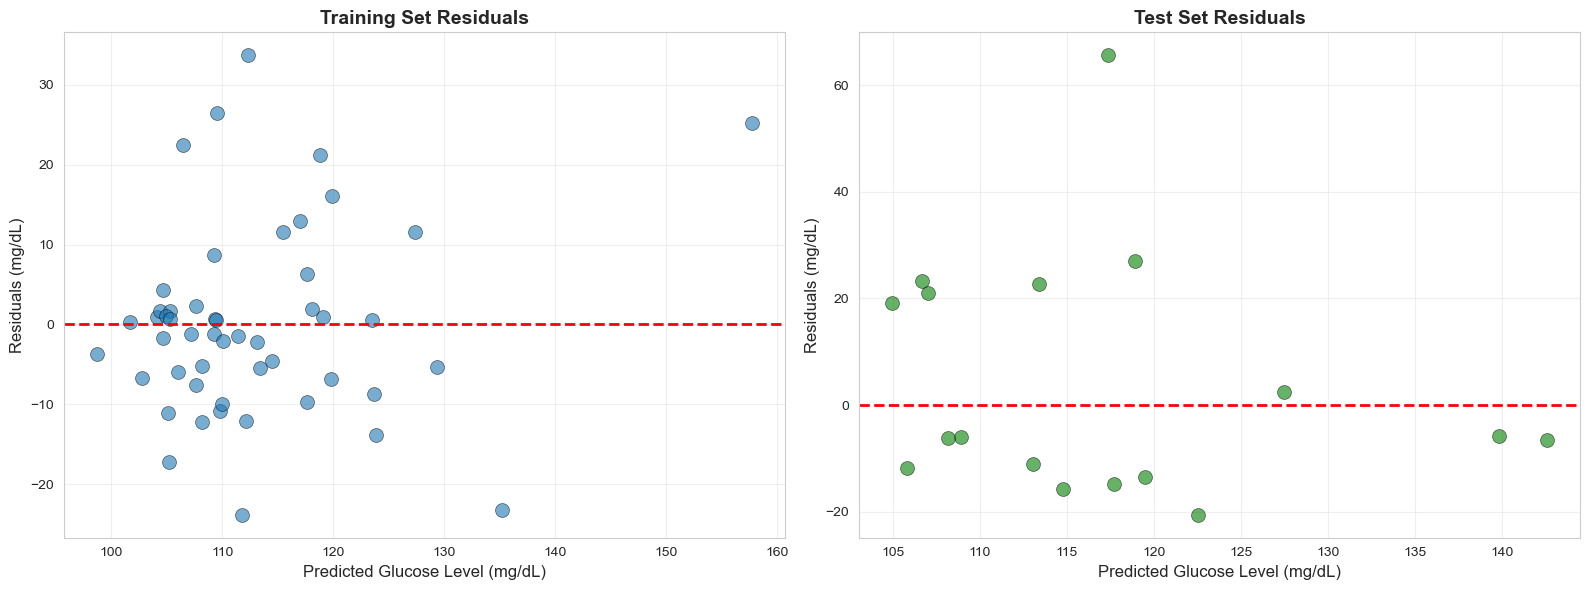

In [12]:
# Residual analysis
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training residuals
axes[0].scatter(y_train_pred, train_residuals, alpha=0.6, s=100, 
                edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Glucose Level (mg/dL)', fontsize=12)
axes[0].set_ylabel('Residuals (mg/dL)', fontsize=12)
axes[0].set_title('Training Set Residuals', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Test residuals
axes[1].scatter(y_test_pred, test_residuals, alpha=0.6, s=100, color='green',
                edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Glucose Level (mg/dL)', fontsize=12)
axes[1].set_ylabel('Residuals (mg/dL)', fontsize=12)
axes[1].set_title('Test Set Residuals', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

Top 15 Most Important Polynomial Features:
weight^2                                :     4.2841
age                                     :     3.6446
age lf_hf_ratio                         :    -3.0876
sdnn age                                :    -3.0669
lf_hf_ratio                             :    -2.7014
mean_hr lf_hf_ratio                     :    -2.0652
age weight                              :     1.9506
lf_hf_ratio weight                      :    -1.9082
num_peaks lf_hf_ratio                   :    -1.7051
num_peaks kurtosis                      :     1.6851
mean_hr kurtosis                        :     1.5722
skewness                                :     1.3656
mean_hr age                             :     1.3189
num_peaks age                           :     1.2499
skewness age                            :    -1.2333


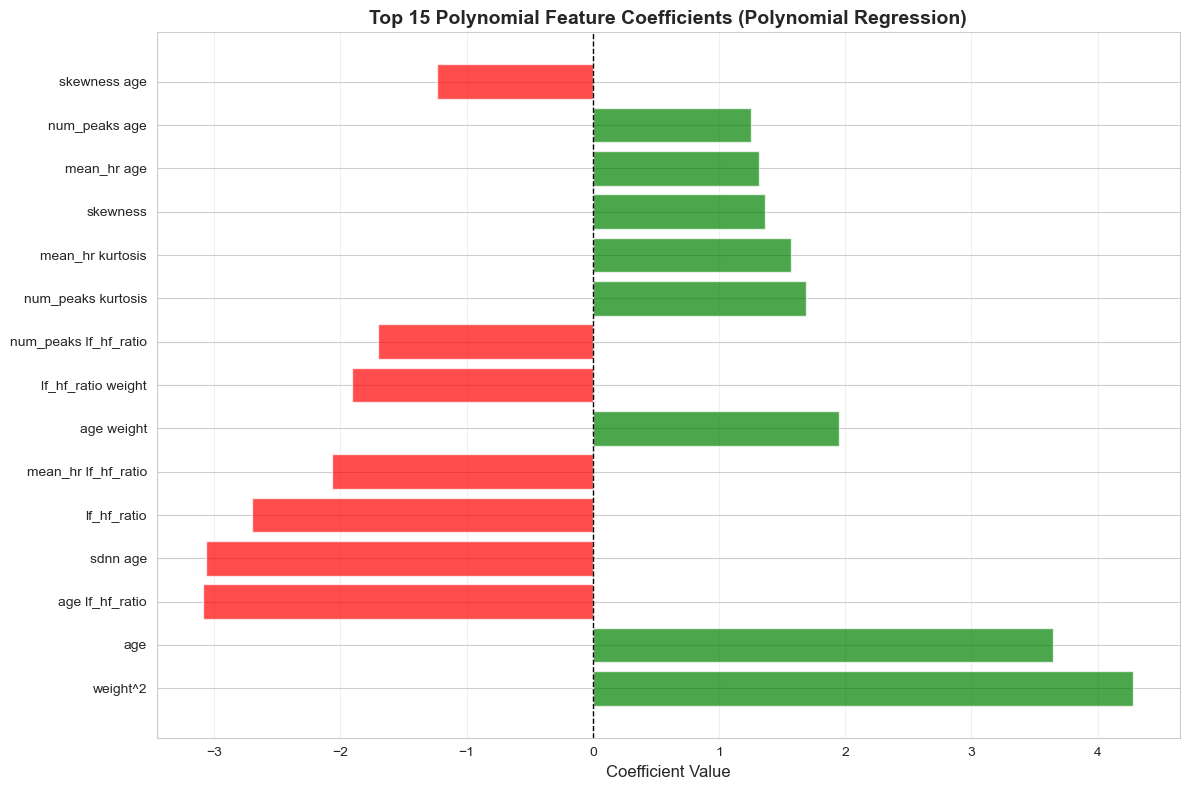

In [13]:
# Get feature coefficients from Ridge regression
ridge_coefs = model.named_steps['ridge'].coef_
poly_feature_names = model.named_steps['poly'].get_feature_names_out(top_features)

# Create feature importance based on absolute coefficient values
feature_importance = pd.DataFrame({
    'feature': poly_feature_names,
    'coefficient': ridge_coefs,
    'abs_coefficient': np.abs(ridge_coefs)
}).sort_values('abs_coefficient', ascending=False)

# Show top 15 most important features
print("Top 15 Most Important Polynomial Features:")
print("=" * 70)
for idx, row in feature_importance.head(15).iterrows():
    print(f"{row['feature']:40}: {row['coefficient']:10.4f}")

# Visualize top 15 feature coefficients
plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
colors = ['green' if x > 0 else 'red' for x in top_15['coefficient']]
plt.barh(range(len(top_15)), top_15['coefficient'].values, color=colors, alpha=0.7)
plt.yticks(range(len(top_15)), top_15['feature'].values, fontsize=10)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 Polynomial Feature Coefficients (Polynomial Regression)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Save Model for Deployment

In [14]:
# Save the trained model
import pickle

model_filename = 'glucose_prediction_model.pkl'
scaler_filename = 'feature_scaler.pkl'

# Save model
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

# Save scaler
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names_file = 'model_features.txt'
with open(feature_names_file, 'w') as f:
    f.write('\n'.join(top_features))

print(f"Model saved to: {model_filename}")
print(f"Scaler saved to: {scaler_filename}")
print(f"Feature names saved to: {feature_names_file}")


Model saved to: glucose_prediction_model.pkl
Scaler saved to: feature_scaler.pkl
Feature names saved to: model_features.txt
